### Implementing simple Chatbot Using LangGraph


In [1]:
from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END

## Reducers
from typing import Annotated
from langgraph.graph.message import add_messages

In [2]:
class State(TypedDict):
    messages:Annotated[list,add_messages]

In [3]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["OPENAI_API_KEY"]=os.getenv("OPENAI_API_KEY")
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")


In [4]:
from langchain_openai import ChatOpenAI
llm=ChatOpenAI(model="gpt-4o-mini-2024-07-18")
llm.invoke("Hello")

AIMessage(content='Hello! How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 9, 'prompt_tokens': 8, 'total_tokens': 17, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_33a9b387c2', 'id': 'chatcmpl-E7PJc9m3YrILhSLG3kETCMh4jUSSe', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019fb42d-9784-7541-a8ff-f8a06af44f70-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 8, 'output_tokens': 9, 'total_tokens': 17, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

In [9]:
from langchain_groq import ChatGroq

llm_groq=ChatGroq(model="qwen/qwen3.6-27b")
llm_groq.invoke("Hey I am Jahid and i like to play cricket")

AIMessage(content='\n<think>\nHere\'s a thinking process:\n\n1.  **Analyze User Input:**\n   - Name: Jahid\n   - Interest: Likes to play cricket\n   - Tone: Casual, friendly ("Hey I am Jahid and i like to play cricket")\n\n2.  **Identify Key Elements to Respond To:**\n   - Acknowledge the name (Jahid)\n   - Acknowledge the interest (cricket)\n   - Keep the tone friendly and engaging\n   - Ask follow-up questions to keep the conversation going\n   - Optionally share relevant cricket-related info or enthusiasm\n\n3.  **Determine Response Goals:**\n   - Be welcoming and personalized\n   - Show interest in cricket\n   - Ask about his role, favorite team, playing experience, etc.\n   - Keep it open-ended for further conversation\n\n4.  **Draft Response (Mental Refinement):**\n   Hey Jahid! Nice to meet you. Cricket’s an amazing sport—there’s nothing quite like the thrill of a well-played match. Are you more of a bowler, a batter, or do you enjoy all-round play? Also, who’s your favorite tea

### We Will start With Creating Nodes

In [15]:
from langgraph.checkpoint.memory import MemorySaver
memory=MemorySaver()
def superbot(state:State):
    return {"messages":[llm.invoke(state['messages'])]}

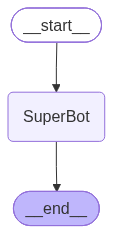

In [30]:
graph=StateGraph(State)

## node
graph.add_node("SuperBot",superbot)
## Edges

graph.add_edge(START,"SuperBot")
graph.add_edge("SuperBot",END)


graph_builder=graph.compile(checkpointer=memory)


## Display
from IPython.display import Image, display
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [17]:
## Invocation

config = {"configurable": {"thread_id": "1"}}

graph_builder.invoke({'messages':"Hi,My name is Jahid And I like cricket"},config)

{'messages': [HumanMessage(content='Hi,My name is Jahid And I like cricket', additional_kwargs={}, response_metadata={}, id='7896ce35-a971-466e-a857-f79d1812da88'),
  AIMessage(content="Hi Jahid! It's great to meet you. Cricket is such an exciting sport! Do you have a favorite team or player?", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 26, 'prompt_tokens': 18, 'total_tokens': 44, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_640d72f4a5', 'id': 'chatcmpl-E7PPYJrWZIE1tuet16gL8IXPoPAQR', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019fb433-3516-7bd3-ae33-6b7e06af55f4-0', tool_calls=[], invalid_tool_calls=[], usage_metadata=

### Streaming 
Methods: .stream() and astream()

- These methods are sync and async methods for streaming back results.

Additional parameters in streaming modes for graph state

- **values** : This streams the full state of the graph after each node is called.
- **updates** : This streams updates to the state of the graph after each node is called.

In [25]:
# Create a thread
config = {"configurable": {"thread_id": "2"}}

for chunk in graph_builder.stream({'messages':"Hi,My name is Jahid Hasan And I like cricket"},config,stream_mode="updates"):
    print(chunk)

{'SuperBot': {'messages': [AIMessage(content='Hi Jahid Hasan! It’s great to meet you! Cricket is an amazing sport with a rich history and a lot of excitement. Do you have a favorite team or player? What do you enjoy most about cricket?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 44, 'prompt_tokens': 362, 'total_tokens': 406, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_33a9b387c2', 'id': 'chatcmpl-E7PUosCxHiLgmCA0O0d0xUoR2tUEh', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019fb438-2f6c-7772-8185-65c7d5a6634c-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 362, 'output_tokens': 44, 'total_tokens

In [26]:
for chunk in graph_builder.stream({'messages':"I also like football"},config,stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi,My name is Jahid Hasan And I like crickrt', additional_kwargs={}, response_metadata={}, id='06dc9ec2-27e2-4793-a246-2e0dbdf0ca36'), AIMessage(content="Hi Jahid Hasan! It's great to hear that you like cricket! What aspects of the game do you enjoy the most? Do you have a favorite team or player?", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 34, 'prompt_tokens': 21, 'total_tokens': 55, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_b1b99e3b92', 'id': 'chatcmpl-E7PPgBVsfm3uTR2IE7GiVmNIT7dXE', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019fb433-5833-7903-a4e6-a0d5242a48e6-0', tool_calls=[

In [22]:
for chunk in graph_builder.stream({'messages':"I also like football "},config,stream_mode="updates"):
    print(chunk)

{'SuperBot': {'messages': [AIMessage(content="It sounds like you're really passionate about football! Since we’ve established that you like both cricket and football, how about sharing what you enjoy most about each sport? Maybe you have a favorite match or player in football that stands out to you?", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 48, 'prompt_tokens': 238, 'total_tokens': 286, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_33a9b387c2', 'id': 'chatcmpl-E7PRwvQcRnAiNdKsv29c4YQxshiFe', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019fb435-798c-7b23-b8d4-5932134affcd-0', tool_calls=[], invalid_tool_calls=[], usage_

In [27]:
for chunk in graph_builder.stream({'messages':"I Love sports "},config,stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi,My name is Jahid Hasan And I like crickrt', additional_kwargs={}, response_metadata={}, id='06dc9ec2-27e2-4793-a246-2e0dbdf0ca36'), AIMessage(content="Hi Jahid Hasan! It's great to hear that you like cricket! What aspects of the game do you enjoy the most? Do you have a favorite team or player?", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 34, 'prompt_tokens': 21, 'total_tokens': 55, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_b1b99e3b92', 'id': 'chatcmpl-E7PPgBVsfm3uTR2IE7GiVmNIT7dXE', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019fb433-5833-7903-a4e6-a0d5242a48e6-0', tool_calls=[

In [28]:
for chunk in graph_builder.stream({'messages':"I Love Reading "},config,stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi,My name is Jahid Hasan And I like crickrt', additional_kwargs={}, response_metadata={}, id='06dc9ec2-27e2-4793-a246-2e0dbdf0ca36'), AIMessage(content="Hi Jahid Hasan! It's great to hear that you like cricket! What aspects of the game do you enjoy the most? Do you have a favorite team or player?", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 34, 'prompt_tokens': 21, 'total_tokens': 55, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_b1b99e3b92', 'id': 'chatcmpl-E7PPgBVsfm3uTR2IE7GiVmNIT7dXE', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019fb433-5833-7903-a4e6-a0d5242a48e6-0', tool_calls=[

#### Streaming The Responses With astream Method

**Streaming tokens**
We often want to stream more than graph state.

In particular, with chat model calls it is common to stream the **tokens** as they are generated.

We can do this using the .astream_events method, which streams back events as they happen inside nodes!

Each event is a dict with a few keys:

- event: This is the type of event that is being emitted.
- name: This is the name of event.
- data: This is the data associated with the event.
- metadata: Containslanggraph_node, the node emitting the event.

astream is specially helpful in debugging <br>

In [31]:
config = {"configurable": {"thread_id": "2"}}

async for event in graph_builder.astream_events({"messages":["Hi My name is Krish and I like to play cricket"]},config,version="v2"):
    print(event)

{'event': 'on_chain_start', 'data': {'input': {'messages': ['Hi My name is Krish and I like to play cricket']}}, 'name': 'LangGraph', 'tags': [], 'run_id': '019fb43c-cfe6-7763-b80c-1fa00a7cba5b', 'metadata': {'thread_id': '2', 'ls_integration': 'langgraph'}, 'parent_ids': []}
{'event': 'on_chain_start', 'data': {'input': {'messages': [HumanMessage(content='Hi,My name is Jahid Hasan And I like crickrt', additional_kwargs={}, response_metadata={}, id='06dc9ec2-27e2-4793-a246-2e0dbdf0ca36'), AIMessage(content="Hi Jahid Hasan! It's great to hear that you like cricket! What aspects of the game do you enjoy the most? Do you have a favorite team or player?", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 34, 'prompt_tokens': 21, 'total_tokens': 55, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_token